# Risques environnementaux — analyse spatio-temporelle (NASA EONET)

**Angle décisionnel** — support à la **gestion de crise et à la résilience** :
identifier les zones à forte exposition aux aléas naturels, comprendre leurs
dynamiques saisonnières et anticiper la fréquence à venir, pour aider au
pré-positionnement des moyens.

**Données** — API **NASA EONET v3** (*Earth Observatory Natural Event Tracker*),
événements naturels géolocalisés et datés (incendies, tempêtes, volcans,
inondations, glace…), agrégés depuis des sources faisant autorité. Ingestion
reproductible paginée par année : **47 327 points d'observation** sur **≈19 500
événements distincts** (2012–2026).

**Plan**
1. Ingestion & structuration spatio-temporelle
2. EDA — dynamiques temporelles, géographie, saisonnalité
3. Hotspots (DBSCAN spatial)
4. Prévision de fréquence (Prophet)
5. Indice de risque composite par zone
6. Conclusions & limites

> Point méthodo clé : un événement = plusieurs points de trajectoire. On compte
> donc les **événements distincts** (pas les points bruts), sinon une tempête
> longuement suivie écraserait des centaines d'incendies ponctuels.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Image, display

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "src"))

from preprocessing import load_clean

df = load_clean()
events = df.sort_values("date").groupby("event_id", as_index=False).first()
print(f"{len(df):,} points d'observation | {events.event_id.nunique():,} "
      f"événements distincts | {df.year.min()}-{df.year.max()}")
df.head()

47,327 points d'observation | 19,444 événements distincts | 2011-2026


,event_id,title,category,category_title,source,date,lon,lat,magnitude,magnitude_unit,closed,year,month,season,is_open,region,cell_lon,cell_lat,cell
0,EONET_1317,Cyclone Freda,severeStorms,Severe Storms,UNISYS,2012-12-28 12:00:00+00:00,160.5,-10.7,NaN,NaN,2013-01-05T00:00:00Z,2012,12,DJF,False,Oceania,160,-15,160_-15
1,EONET_1317,Cyclone Freda,severeStorms,Severe Storms,UNISYS,2012-12-29 00:00:00+00:00,159.9,-12.6,NaN,NaN,2013-01-05T00:00:00Z,2012,12,DJF,False,Oceania,155,-15,155_-15
2,EONET_1317,Cyclone Freda,severeStorms,Severe Storms,UNISYS,2012-12-29 12:00:00+00:00,160.4,-12.9,NaN,NaN,2013-01-05T00:00:00Z,2012,12,DJF,False,Oceania,160,-15,160_-15
3,EONET_1317,Cyclone Freda,severeStorms,Severe Storms,UNISYS,2012-12-30 00:00:00+00:00,160.7,-14.1,NaN,NaN,2013-01-05T00:00:00Z,2012,12,DJF,False,Oceania,160,-15,160_-15
4,EONET_1317,Cyclone Freda,severeStorms,Severe Storms,UNISYS,2012-12-30 12:00:00+00:00,161.1,-15.3,NaN,NaN,2013-01-05T00:00:00Z,2012,12,DJF,False,Oceania,160,-20,160_-20


## 1. Points d'observation vs événements distincts

La différence est structurante : au niveau des **points bruts**, les tempêtes
dominent (trajectoires longues) ; au niveau des **événements**, ce sont les
incendies (nombreux et ponctuels).

In [2]:
comp = pd.DataFrame({
    "points bruts": df.category_title.value_counts(),
    "événements distincts": events.category_title.value_counts(),
}).fillna(0).astype(int).head(6)
display(comp)

,points bruts,événements distincts
category_title,,
Drought,7,7
Dust and Haze,17,17
Earthquakes,15,15
Floods,772,772
Landslides,2,2
Manmade,5,5


## 2. EDA spatio-temporelle

Volume annuel, concentration géographique par type d'aléa, et saisonnalité.

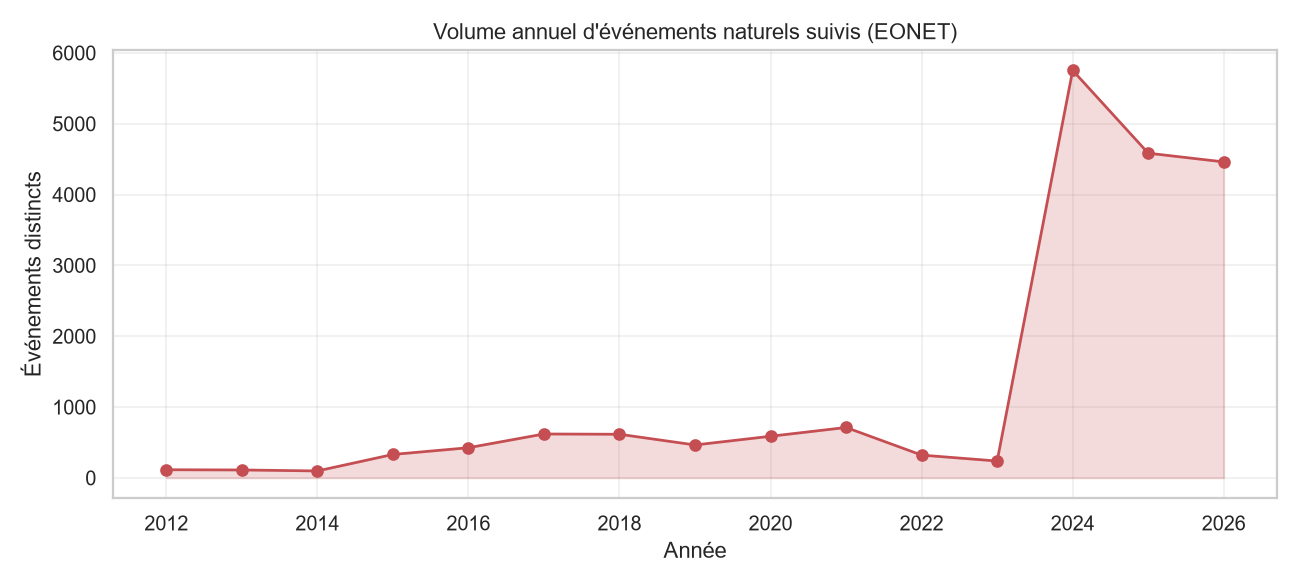

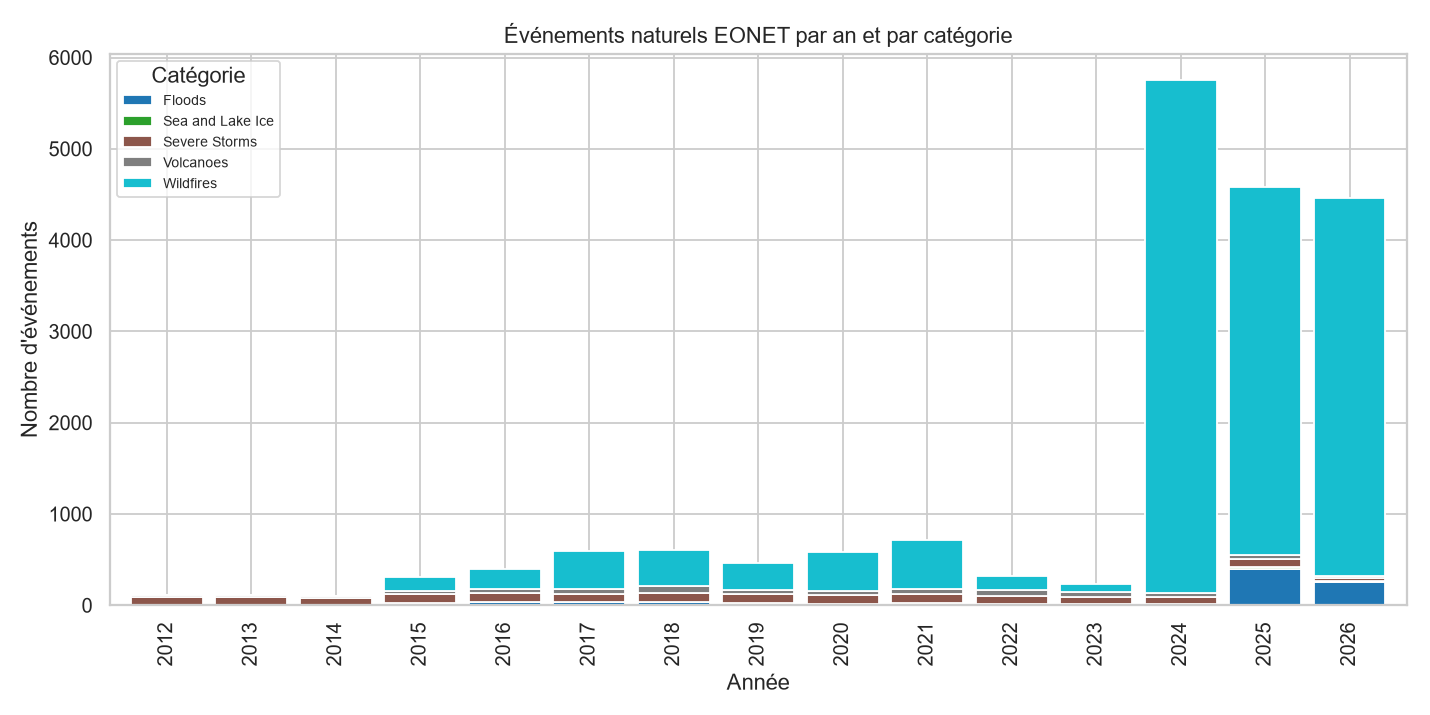

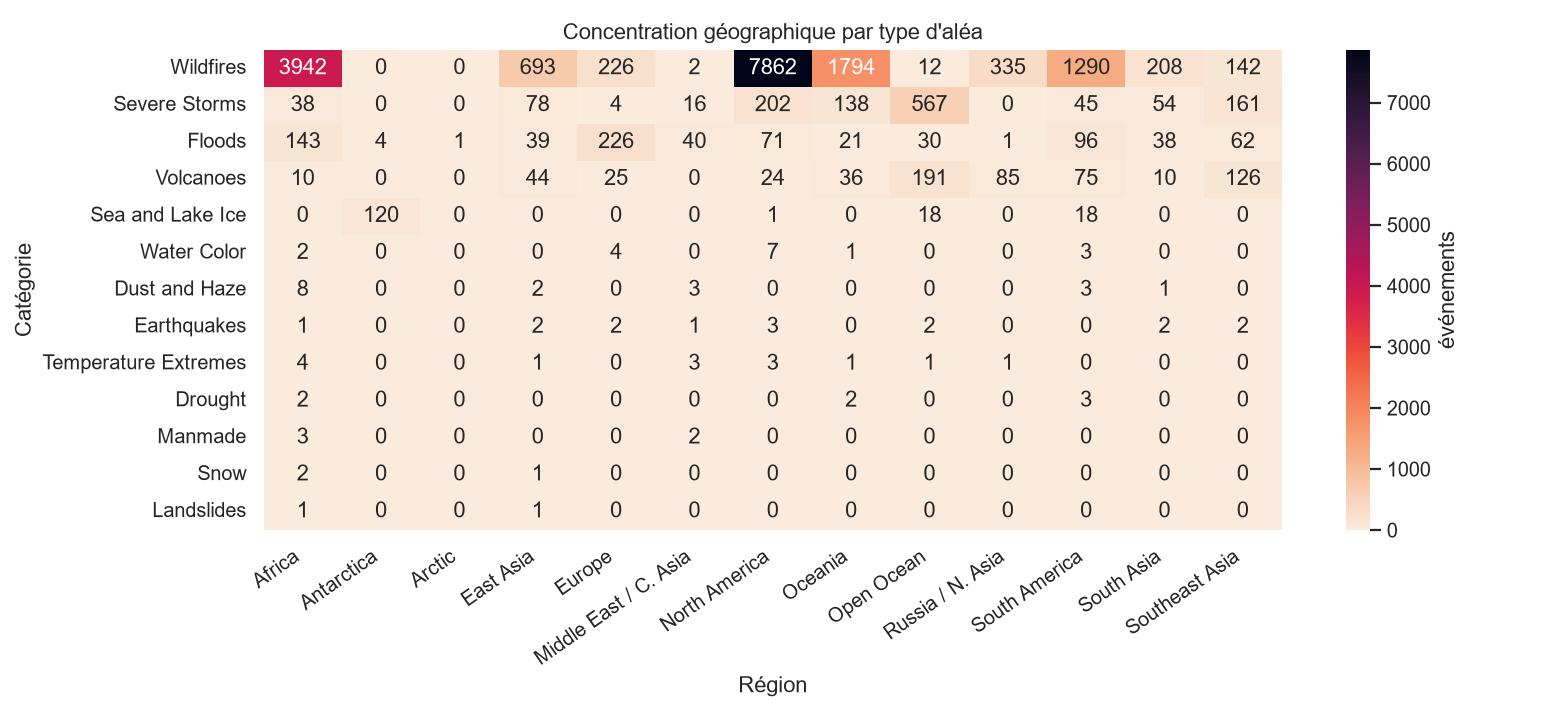

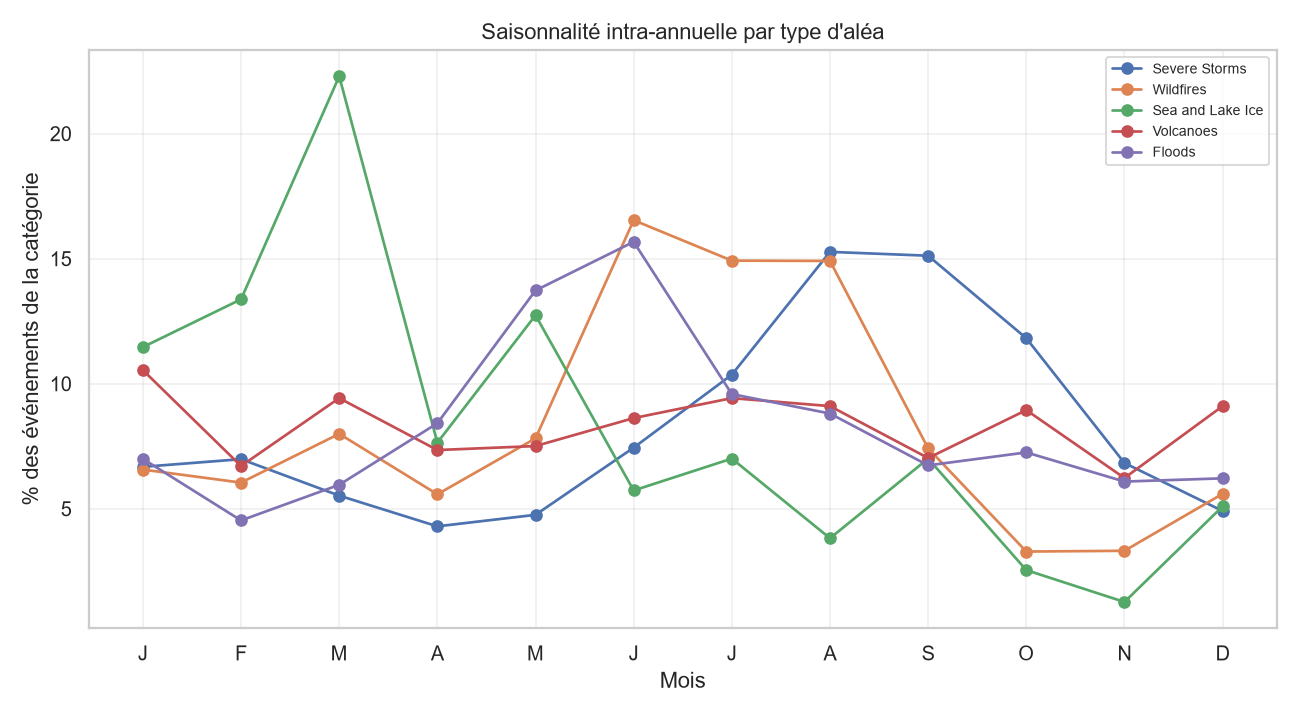

In [3]:
for fig in ["events_trend.png", "events_per_year.png",
            "category_region_heatmap.png", "seasonality.png"]:
    display(Image(ROOT / "reports" / "figures" / fig, width=780))

**Lecture** — le volume d'événements suivis explose à partir de 2024 (montée en
charge des sources EONET, à ne pas confondre avec une hausse physique des
aléas — voir *Limites*). La heatmap catégorie × région montre des signatures
nettes : incendies concentrés en Amérique du Nord et Afrique, glace de mer aux
pôles. La saisonnalité confirme des cycles annuels marqués (saison des feux,
saison des tempêtes) — ce qui justifie le choix de Prophet en §4.

## 3. Hotspots géographiques (DBSCAN)

DBSCAN sur la métrique **haversine** (eps = 150 km, min_samples = 30) regroupe
les incendies en zones denses récurrentes, sans fixer le nombre de clusters.
Les événements isolés (bruit) sont exclus.

31 hotspots d'incendies détectés


,cluster,n_events,lat,lon,top_region,first_year,last_year
0,0,6332,38.47,-108.03,North America,2014,2026
1,19,1382,7.40,26.92,Africa,2024,2026
2,4,1256,-16.27,131.10,Oceania,2015,2026
3,1,885,-7.19,20.83,Africa,2024,2026
4,5,491,54.94,-99.96,North America,2017,2026
5,7,387,-16.28,-60.29,South America,2017,2026
6,24,370,18.87,99.43,East Asia,2016,2026
7,11,282,53.52,115.61,East Asia,2024,2026


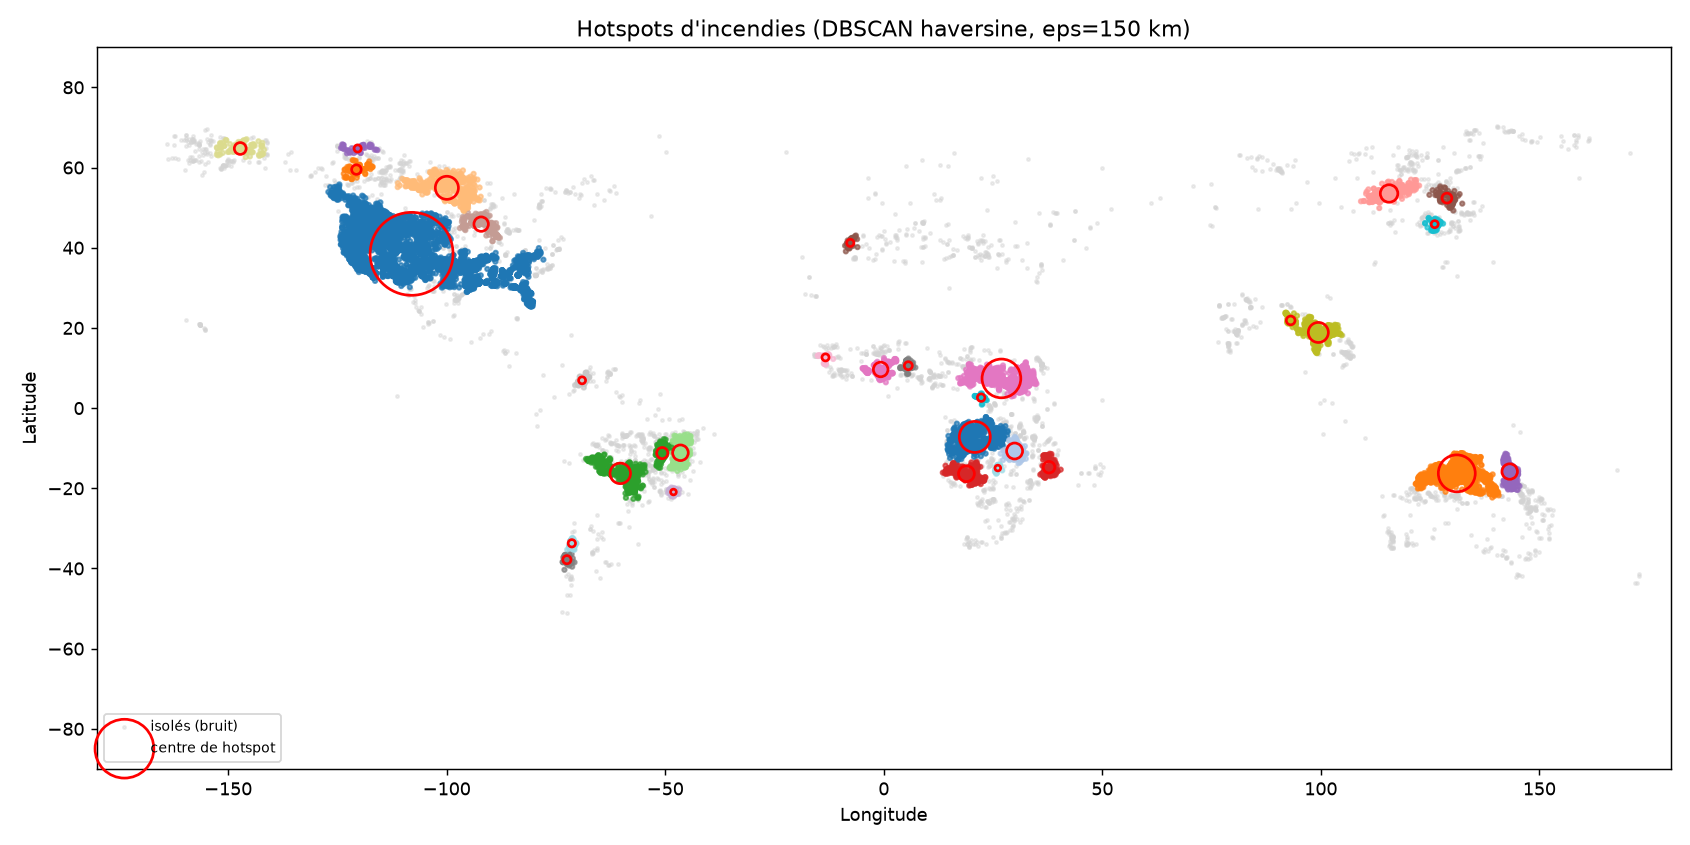

In [4]:
hot = pd.read_csv(ROOT / "reports" / "hotspots.csv")
print(f"{len(hot)} hotspots d'incendies détectés")
display(hot.head(8).round(2))
display(Image(ROOT / "reports" / "figures" / "wildfire_hotspots.png", width=860))

Le plus gros hotspot (>6 000 événements, ouest de l'Amérique du Nord) domine,
suivi de vastes zones en Afrique subsaharienne et dans le nord de l'Australie.
La carte interactive `reports/figures/eonet_hotspots_map.html` permet de zoomer.

## 4. Prévision de fréquence (Prophet)

Séries de comptages **mensuels** d'événements distincts, Prophet avec
saisonnalité annuelle multiplicative, horizon 18 mois.

,category,next12m_projected,next12m_low,next12m_high,last12m_actual
0,Wildfires,6722.0,4365.0,9073.0,6275.0
1,Severe Storms,90.0,51.0,127.0,93.0
2,Floods,534.0,427.0,638.0,527.0


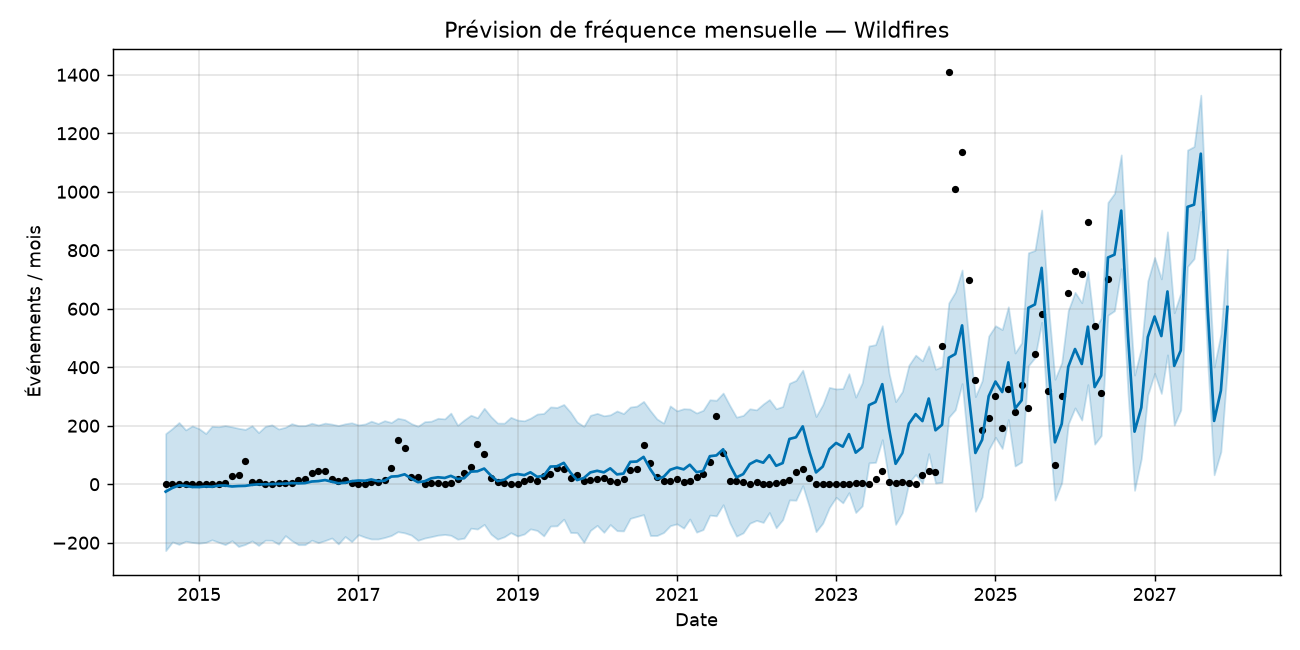

In [5]:
fc = pd.read_csv(ROOT / "reports" / "forecast_summary.csv")
display(fc.round(0))
display(Image(ROOT / "reports" / "figures" / "forecast_wildfires.png", width=760))

**Validation de bon sens** — le total projeté sur 12 mois est proche du réalisé
des 12 derniers mois pour chaque catégorie (ex. incendies : ~6 700 projetés vs
6 275 réalisés), et l'intervalle à 80 % encadre bien la saisonnalité. Le modèle
capture le cycle annuel, pas des chocs ponctuels — c'est attendu.

## 5. Indice de risque composite par zone

Faute d'un champ de sévérité homogène entre catégories, l'indice combine trois
composantes normalisées par cellule/région :
**fréquence** (log), **récence** (part des événements des 3 dernières années),
**diversité** (nombre de types d'aléas). Pondération 0,5 / 0,3 / 0,2.

,region,n_events,n_categories,recency,risk_index
0,Africa,4156,12,0.974,0.950
1,North America,8173,8,0.684,0.811
2,Oceania,1993,7,0.909,0.791
3,South America,1533,8,0.833,0.765
4,East Asia,861,9,0.869,0.762
5,South Asia,313,6,0.760,0.607
6,Russia / N. Asia,422,4,0.808,0.606
7,Europe,487,6,0.595,0.573
8,Southeast Asia,493,5,0.483,0.514
9,Middle East / C. Asia,67,7,0.597,0.473


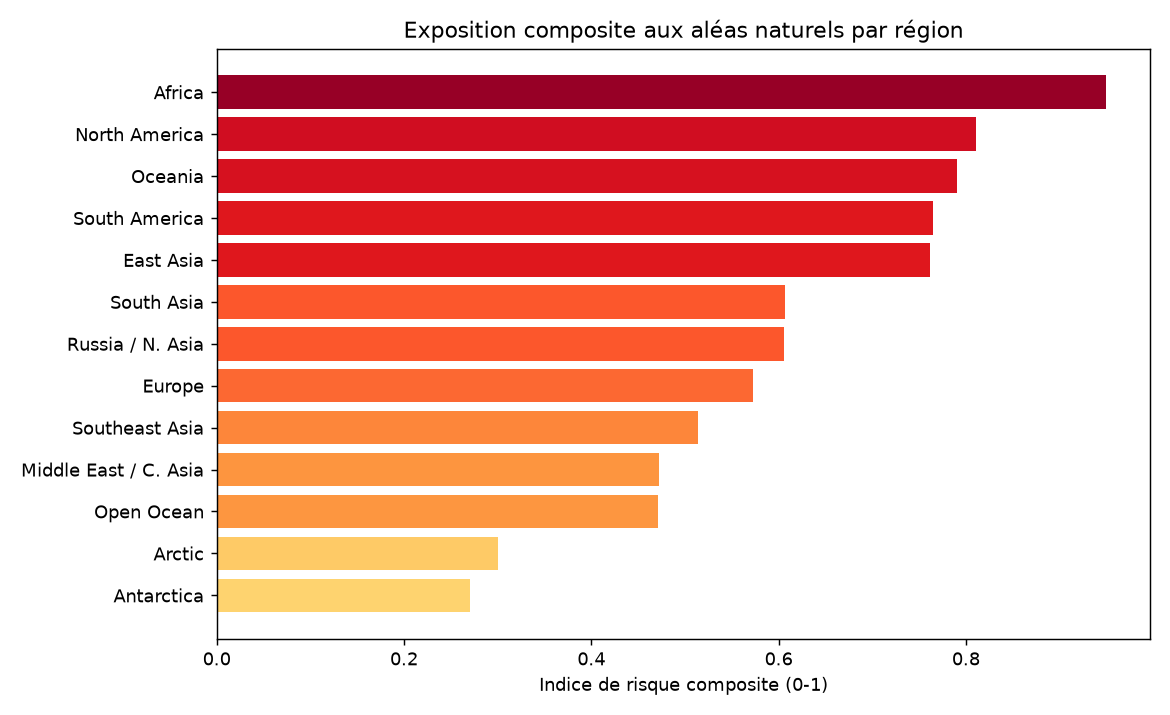

In [6]:
region = pd.read_csv(ROOT / "reports" / "risk_index_region.csv")
display(region[["region", "n_events", "n_categories", "recency",
                "risk_index"]].round(3))
display(Image(ROOT / "reports" / "figures" / "risk_index_region.png", width=680))

**Lecture** — l'Afrique ressort en tête (fréquence élevée, forte récence, 12
types d'aléas), devant l'Amérique du Nord (volume) et l'Océanie (récence). La
carte par cellule 5° `reports/figures/risk_index_map.html` donne le détail
géographique. C'est un score d'**exposition relative**, pas une probabilité
absolue.

## 6. Conclusions & limites

**Conclusions**
- Deux familles de techniques combinées : **clustering spatial non supervisé**
  (DBSCAN) + **séries temporelles** (Prophet), plus un indice composite.
- Signatures géographiques et saisonnières nettes ; hotspots stables ;
  prévisions cohérentes avec l'historique récent.

**Limites (essentielles ici)**
- **Biais de couverture** : EONET agrège des sources dont le nombre et la
  granularité augmentent avec le temps. La forte hausse post-2023 reflète
  surtout un **meilleur reporting**, pas nécessairement plus d'aléas. Les
  comparaisons inter-années sont donc à manier avec prudence.
- **Sévérité manquante** : peu de champs magnitude homogènes → l'indice de
  risque pondère fréquence/récence/diversité, pas l'intensité réelle.
- **Régions par bounding boxes** : approximation grossière (pas de reverse-geo
  fin, pas de frontières administratives).
- L'indice est **relatif et illustratif** : à recalibrer avec des données
  d'exposition/vulnérabilité (population, infrastructures) pour un usage réel.